### Top 10 movies by average rating and most popular Genres

In [39]:
import sys
!{sys.executable} -m pip install pyodbc

import pyodbc
import pandas as pd
import matplotlib.pyplot as plt

# check available ODBC drivers
print("Available ODBC Drivers:")
print(pyodbc.drivers())

# connection string
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=.;"
    "DATABASE=DataLensStreaming;"
    "Trusted_Connection=yes;"
)

# test connection
try:
    cursor = conn.cursor()
    cursor.execute("SELECT 1")
    result = cursor.fetchone()
    print("Connection successful:", result[0])
finally:
    cursor.close()


Available ODBC Drivers:
['SQL Server', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']
Connection successful: 1


In [40]:
df = pd.read_sql("SELECT * FROM dbo.movies_clean", conn)
df.head()
cursor.execute("SELECT DB_NAME()")
print(cursor.fetchone())
cursor = conn.cursor()
cursor.execute("SELECT 'Connection OK'")
print(cursor.fetchone())
df_test = pd.read_sql("SELECT TOP 5 * FROM dbo.Ratings_Dataset", conn)
df_test

C:\Users\sabah\AppData\Local\Temp\ipykernel_19864\673157608.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM dbo.movies_clean", conn)


,MovieID,Movie_Title,Year,Language,Country,Total_Views
0,1,Toy Story,1995,German,Italy,69118
1,2,Jumanji,1995,Spanish,UK,1661
2,3,Grumpier Old Men,1995,English,India,22205
3,4,Waiting to Exhale,1995,Spanish,India,84783
4,5,Father of the Bride Part II,1995,German,India,61291


In [41]:
# Testing the connections and different Queries 
# TEST 1: CHECK DATABASE NAME

cursor = conn.cursor()
cursor.execute("SELECT DB_NAME()")
print("Current Database:", cursor.fetchone()[0])

# -----------------------------
# TEST 2: SIMPLE CONNECTION CHECK
# -----------------------------
cursor.execute("SELECT 'Connection OK'")
print(cursor.fetchone()[0])

cursor.close()

# -----------------------------
# QUERY 1: MOVIES TABLE
# -----------------------------
df = pd.read_sql("SELECT * FROM dbo.movies_clean", conn)
print(df.head())

# -----------------------------
# QUERY 2: RATINGS TABLE (TEST)
# -----------------------------
df_test = pd.read_sql("SELECT TOP 5 * FROM dbo.ratings_clean", conn)
print(df_test)


Current Database: DataLensStreaming
Connection OK
   MovieID                  Movie_Title  Year Language Country  Total_Views
0        1                    Toy Story  1995   German   Italy        69118
1        2                      Jumanji  1995  Spanish      UK         1661
2        3             Grumpier Old Men  1995  English   India        22205
3        4            Waiting to Exhale  1995  Spanish   India        84783
4        5  Father of the Bride Part II  1995   German   India        61291
   RatingID   UserID  MovieID  Rating           Timestamp
0         1  SF_2741     3713     4.1 2024-02-01 04:32:00
1         2  SF_3082     2052     3.1 2024-02-24 04:32:00
2         3    SF_53     3267     4.0 2024-11-12 04:32:00
3         4   SF_182     2517     2.4 2024-09-28 04:32:00
4         5   SF_631     2996     3.1 2024-10-04 04:32:00


C:\Users\sabah\AppData\Local\Temp\ipykernel_19864\2661563059.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM dbo.movies_clean", conn)
C:\Users\sabah\AppData\Local\Temp\ipykernel_19864\2661563059.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_test = pd.read_sql("SELECT TOP 5 * FROM dbo.ratings_clean", conn)


In [45]:
# Query for Top 10 movies by average rating 

query = """
SELECT 
    m.MovieID,
    m.Movie_Title,
    AVG(CAST(r.Rating AS FLOAT)) AS Avg_Rating,
    COUNT(r.Rating) AS Total_Ratings
FROM dbo.movies_clean m
JOIN dbo.ratings_clean r
    ON m.MovieID = r.MovieID
GROUP BY m.MovieID, m.Movie_Title
HAVING COUNT(r.Rating) > 5
ORDER BY Avg_Rating DESC
"""
# load data from SQL
df_top10 = pd.read_sql(query, conn)
# show top 10 in notebook
df_top10.head(10)


C:\Users\sabah\AppData\Local\Temp\ipykernel_19864\1135127338.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_top10 = pd.read_sql(query, conn)


,MovieID,Movie_Title,Avg_Rating,Total_Ratings
0,2228,"Mountain Eagle, The",3.950000,6
1,954,Mr. Smith Goes to Washington,3.942857,7
2,1769,"Replacement Killers, The",3.916667,6
3,2351,Nights of Cabiria (Le Notti di Cabiria),3.837500,8
4,2817,Aces: Iron Eagle III,3.766667,6
5,3630,"House of Exorcism, The (La Casa dell'esorcismo)",3.683333,6
6,734,Getting Away With Murder,3.642857,7
7,316,Stargate,3.633333,6
8,2950,"Blue Lagoon, The",3.616667,6
9,953,It's a Wonderful Life,3.600000,7


In [46]:
# save to CSV
df_top10.to_csv("top10_movies.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


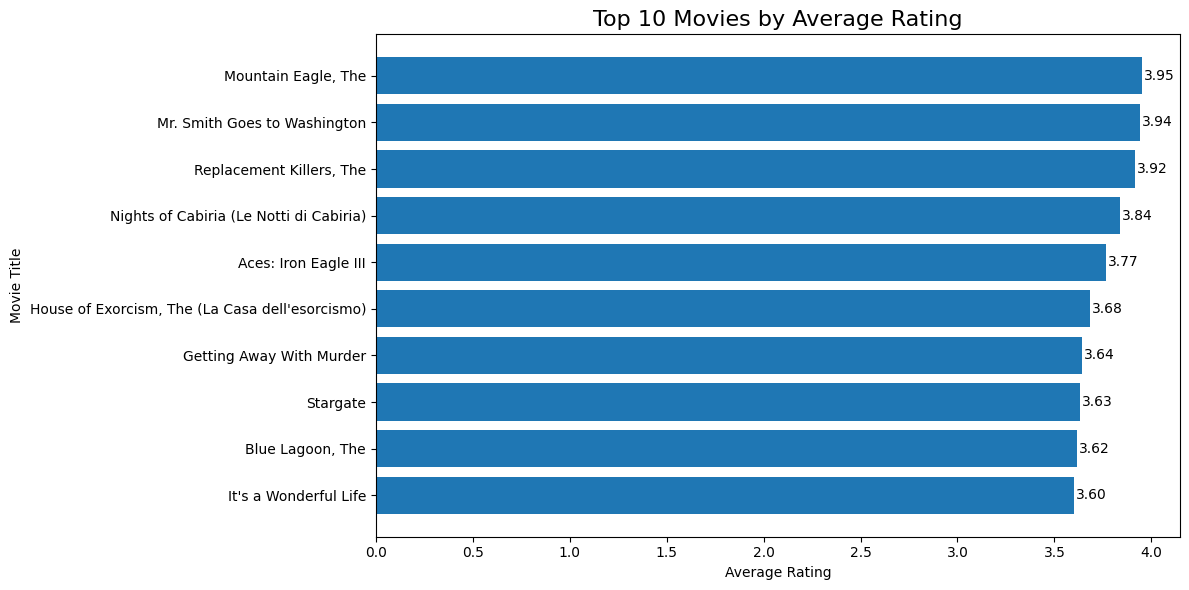

In [19]:
# Bar plot showing top to movies by average Rating  

import matplotlib.pyplot as plt

# Take top 10 after SQL sorting
top10 = df_top10.head(10)

plt.figure(figsize=(12,6))

# Horizontal bar chart (best for long movie titles)
plt.barh(top10["Movie_Title"], top10["Avg_Rating"])

# Highest rating on top
plt.gca().invert_yaxis()

# Titles and labels
plt.title("Top 10 Movies by Average Rating", fontsize=16)
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")

# Add rating labels on bars
for i, rating in enumerate(top10["Avg_Rating"]):
    plt.text(rating + 0.01, i, f"{rating:.2f}", va='center')

plt.tight_layout()
plt.show()

In [47]:

#Query for most popular Genres

query = """
SELECT 
    g.Genre_Name AS Genre,
    COUNT(*) AS Genre_Count
FROM dbo.movie_genres mg
JOIN dbo.genres g
    ON mg.GenreID = g.GenreID
GROUP BY g.Genre_Name
ORDER BY Genre_Count DESC;
"""
# load data from SQL
df_genres = pd.read_sql(query, conn)
# show top  in notebook
df_genres.head(10)

C:\Users\sabah\AppData\Local\Temp\ipykernel_19864\3984496960.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_genres = pd.read_sql(query, conn)


,Genre,Genre_Count
0,Drama,1602
1,Comedy,1199
2,Action,503
3,Thriller,490
4,Romance,471
5,Horror,344
6,Adventure,283
7,Sci-Fi,276
8,Children's,251
9,Crime,210


In [54]:
# save full result to CSV
df_genres.to_csv("most_popular_genres.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


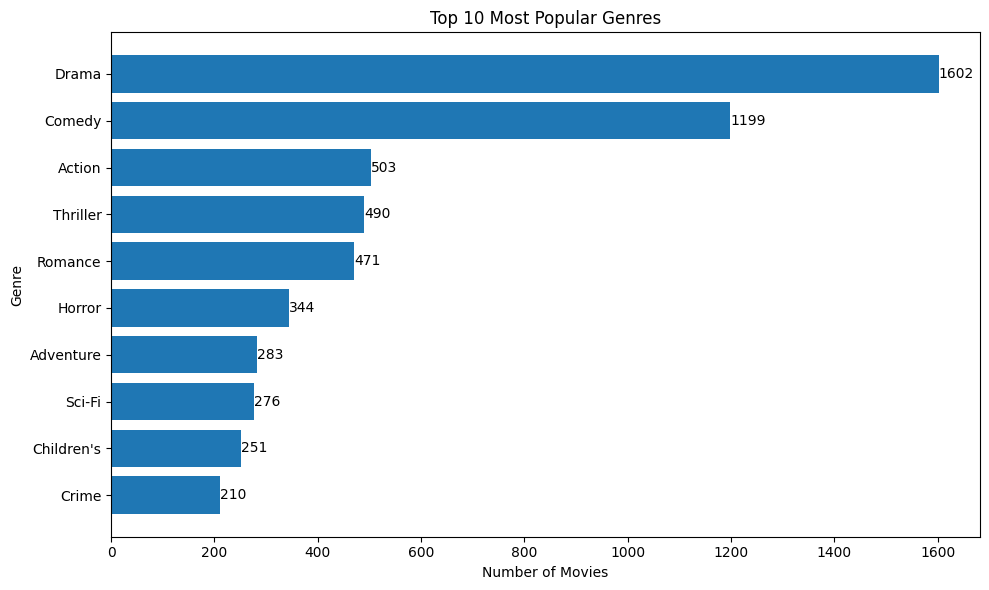

In [48]:
# Bar plot for most popular Genres
import matplotlib.pyplot as plt

top_genres = df_genres.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_genres["Genre"], top_genres["Genre_Count"])
plt.gca().invert_yaxis()

plt.title("Top 10 Most Popular Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

for i, v in enumerate(top_genres["Genre_Count"]):
    plt.text(v, i, str(v), va='center')

plt.tight_layout()
plt.show()

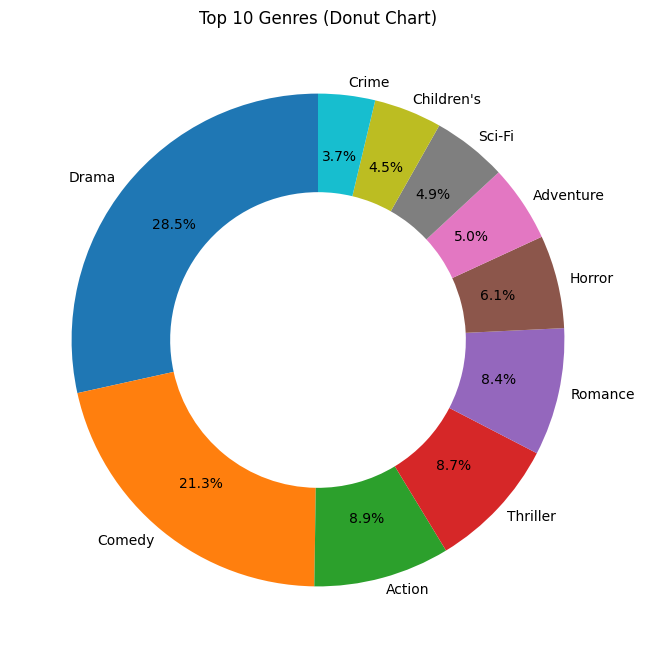

In [49]:
 # Donut plot for most popular Genres

import matplotlib.pyplot as plt

top_genres = df_genres.head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top_genres["Genre_Count"],
    labels=top_genres["Genre"],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,          # 👈 moves % inside
    labeldistance=1.05,        # keeps labels outside nicely
    wedgeprops={'width':0.4}   # donut shape
)

plt.title("Top 10 Genres (Donut Chart)")
plt.show()

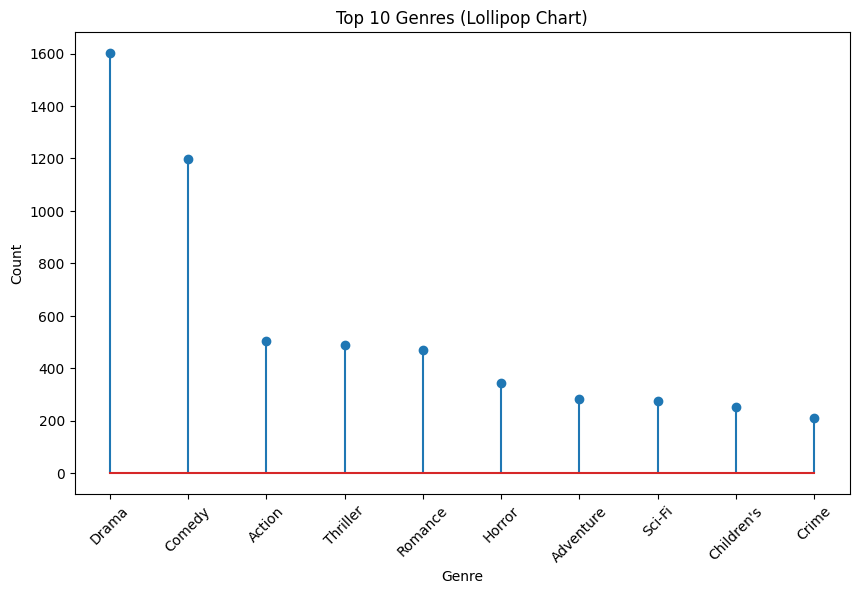

In [50]:
# Lollipop plot showing most popular Genres
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.stem(top_genres["Genre"], top_genres["Genre_Count"])
plt.xticks(rotation=45)

plt.title("Top 10 Genres (Lollipop Chart)")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

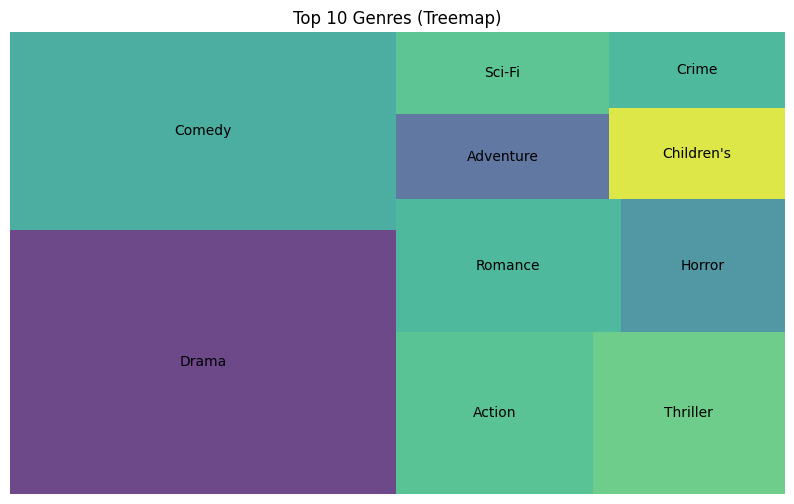

In [51]:
#TreeMap 1 showing most popular genres
!pip install squarify
import sys
!{sys.executable} -m pip install squarify
import squarify
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
squarify.plot(
    sizes=top_genres["Genre_Count"],
    label=top_genres["Genre"],
    alpha=0.8
)

plt.title("Top 10 Genres (Treemap)")
plt.axis("off")
plt.show()

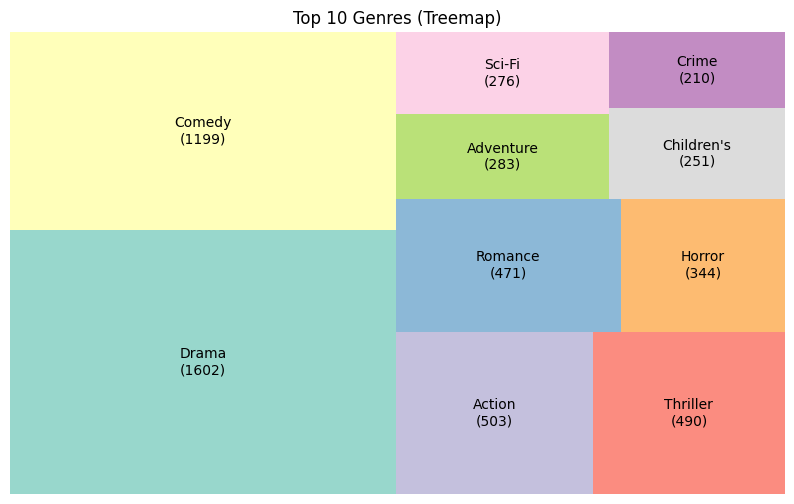

In [52]:
# #TreeMap 2 showing most popular genres 
import squarify
import matplotlib.pyplot as plt
import matplotlib.cm as cm

top_genres = df_genres.head(10)

labels = [
    f"{genre}\n({count})"
    for genre, count in zip(top_genres["Genre"], top_genres["Genre_Count"])
]

# create better color palette
colors = cm.Set3(range(len(top_genres)))  # clean pastel palette

plt.figure(figsize=(10,6))

squarify.plot(
    sizes=top_genres["Genre_Count"],
    label=labels,
    color=colors,   # 👈 improved colors
    alpha=0.9
)

plt.title("Top 10 Genres (Treemap)")
plt.axis("off")
plt.show()

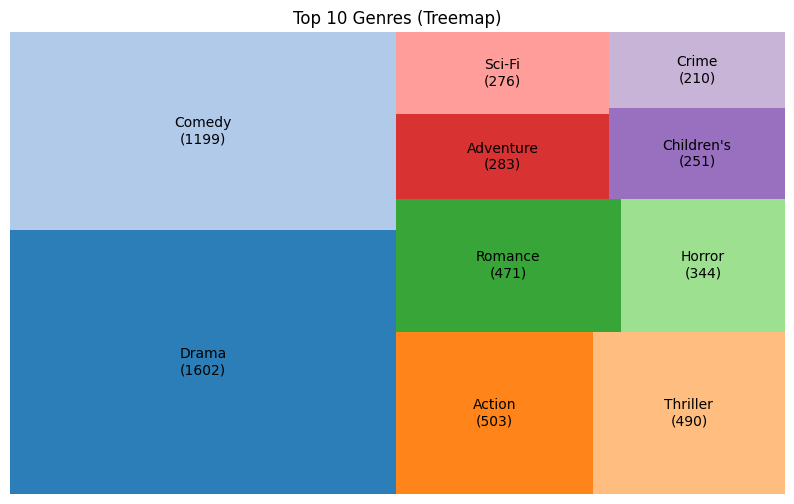

In [53]:
#TreeMap3 showing most popular genres (different colors)
colors = cm.tab20.colors

plt.figure(figsize=(10,6))

squarify.plot(
    sizes=top_genres["Genre_Count"],
    label=labels,
    color=colors,
    alpha=0.95
)

plt.title("Top 10 Genres (Treemap)")
plt.axis("off")
plt.show()